In [7]:
import numpy as np
from scipy.linalg import sqrtm
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# Simulation of OU dynamic factor model
# -------------------------------
def simulate_ou_dfa(n_subjects=500, T=5, p=8000, k=3, rho=0.05, Q=1.0, Psi_scale=0.5, seed=0):
    np.random.seed(seed)
    # Loading matrix
    Lambda = np.random.randn(p,k)
    # Observation noise
    Psi = np.diag(np.random.rand(p)*Psi_scale)
    # Latent states
    Zs = []
    Ys = []
    dts = []
    for i in range(n_subjects):
        dt = np.ones(T-1)  # uniform dt
        dts.append(dt)
        z = np.zeros((T,k))
        z[0] = np.random.randn(k)
        for t in range(1,T):
            z[t] = np.exp(-rho*dt[t-1])*z[t-1] + np.random.multivariate_normal(np.zeros(k), Q*np.eye(k))
        y = z @ Lambda.T + np.random.multivariate_normal(np.zeros(p), Psi, size=T)
        Ys.append(y)
        Zs.append(z)
    return Ys, Zs, Lambda, dts

# -------------------------------
# Kalman smoother for E-step
# -------------------------------
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]
    Ez = np.zeros((T,k))
    Ezz = np.zeros((T,k,k))
    # Initialize
    m = np.zeros(k)
    P = np.eye(k)
    R = Psi
    eps = 1e-5
    # Forward pass
    for t in range(T):
        A = np.exp(-rho*dt[t-1] if t>0 else 0)*np.eye(k)
        P = A @ P @ A.T + Q*np.eye(k)
        S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P
        Ez[t] = m
        Ezz[t] = P + np.outer(m,m)
    return Ez, Ezz, None  # lag cov not used

# -------------------------------
# Update Lambda with horseshoe shrinkage
# -------------------------------
def update_Lambda(Ez_all, Ezz_all, Y_all, tau, lam, eps=1e-5):
    n_subjects, T, k = Ez_all.shape
    p = Y_all.shape[1]
    Lambda = np.zeros((p,k))

    # Sum over subjects/time
    Ezz_sum = np.zeros((k,k))
    Ezy_sum = np.zeros((k,p))
    for i in range(n_subjects):
        for t in range(T):
            Ezz_sum += Ezz_all[i,t]
            Ezy_sum += np.outer(Ez_all[i,t], Y_all[i*T + t])

    for j in range(p):
        ridge = np.diag(1.0/(tau[j]*lam**2 + eps))
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:,j])
    return Lambda

# -------------------------------
# Update Psi (diagonal)
# -------------------------------
def update_Psi(Ys, Ezs, Ezzs, Lambda):
    p,k = Lambda.shape
    Psi = np.zeros(p)
    for j in range(p):
        num = 0.0
        den = 0
        for Y, Ez, Ezz in zip(Ys, Ezs, Ezzs):
            T = Y.shape[0]
            for t in range(T):
                res = Y[t,j] - Lambda[j] @ Ez[t]
                num += res**2 + Lambda[j] @ Ezz[t] @ Lambda[j].T
                den += 1
        Psi[j] = num/den
    return np.diag(Psi)

# -------------------------------
# EM algorithm
# -------------------------------
def run_em(Ys, dts, k=3, n_iter=30):
    n_subjects = len(Ys)
    T = Ys[0].shape[0]
    p = Ys[0].shape[1]

    # Initialize parameters
    Lambda = np.random.randn(p,k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0

    # Horseshoe shrinkage params
    tau = np.ones(p)
    lam = np.ones(k)

    Y_all = np.vstack(Ys)

    for it in range(n_iter):
        # -------------------------------
        # E-step
        # -------------------------------
        Ezs, Ezzs = [], []
        for Y, dt in zip(Ys, dts):
            Ez, Ezz, _ = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)
        Ez_all = np.array(Ezs)
        Ezz_all = np.array(Ezzs)

        # -------------------------------
        # M-step
        # -------------------------------
        Lambda = update_Lambda(Ez_all, Ezz_all, Y_all, tau, lam)
        Psi = update_Psi(Ys, Ezs, Ezzs, Lambda)

        # Simple OU updates (mean squared differences)
        diffs = []
        for Ez, dt in zip(Ezs, dts):
            for t in range(1,T):
                diffs.append(Ez[t]-Ez[t-1])
        diffs = np.array(diffs)
        Q = np.mean(np.var(diffs, axis=0))
        rho = 0.05  # keep small fixed

        print(f"Iter {it:02d} | rho={rho:.3f} | Q={Q:.3f} | mean|Λ|={np.mean(np.abs(Lambda)):.3f}")

    return Lambda

# -------------------------------
# Factor recovery (Procrustes)
# -------------------------------
def factor_recovery(L_true, L_est):
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    corr = np.corrcoef(L_aligned.flatten(), L_true.flatten())[0,1]
    return corr

# -------------------------------
# Main function
# -------------------------------
def main():
    Ys, Zs, Lambda_true, dts = simulate_ou_dfa(
        n_subjects=60,
        T=5,
        p=10,
        k=3,
        rho=0.05,
        Q=1.0,
        Psi_scale=0.5
    )

    Lambda_est = run_em(Ys, dts, k=3, n_iter=30)
    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

if __name__=="__main__":
    main()


Iter 00 | rho=0.050 | Q=0.526 | mean|Λ|=0.911
Iter 01 | rho=0.050 | Q=0.397 | mean|Λ|=0.891
Iter 02 | rho=0.050 | Q=0.363 | mean|Λ|=0.900
Iter 03 | rho=0.050 | Q=0.328 | mean|Λ|=0.913
Iter 04 | rho=0.050 | Q=0.301 | mean|Λ|=0.931
Iter 05 | rho=0.050 | Q=0.280 | mean|Λ|=0.951
Iter 06 | rho=0.050 | Q=0.262 | mean|Λ|=0.971
Iter 07 | rho=0.050 | Q=0.246 | mean|Λ|=0.991
Iter 08 | rho=0.050 | Q=0.233 | mean|Λ|=1.010
Iter 09 | rho=0.050 | Q=0.222 | mean|Λ|=1.029
Iter 10 | rho=0.050 | Q=0.211 | mean|Λ|=1.048
Iter 11 | rho=0.050 | Q=0.202 | mean|Λ|=1.065
Iter 12 | rho=0.050 | Q=0.194 | mean|Λ|=1.082
Iter 13 | rho=0.050 | Q=0.187 | mean|Λ|=1.096
Iter 14 | rho=0.050 | Q=0.181 | mean|Λ|=1.110
Iter 15 | rho=0.050 | Q=0.175 | mean|Λ|=1.123
Iter 16 | rho=0.050 | Q=0.170 | mean|Λ|=1.136
Iter 17 | rho=0.050 | Q=0.165 | mean|Λ|=1.148
Iter 18 | rho=0.050 | Q=0.161 | mean|Λ|=1.159
Iter 19 | rho=0.050 | Q=0.157 | mean|Λ|=1.169
Iter 20 | rho=0.050 | Q=0.154 | mean|Λ|=1.177
Iter 21 | rho=0.050 | Q=0.150 | me

In [8]:
import numpy as np
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# Simulation
# -------------------------------
def simulate_ou_dfa(n_subjects=50, T_list=None, p=7000, k=3, rho=0.05, Q=1.0, Psi_scale=0.5, seed=0):
    np.random.seed(seed)
    Lambda = np.random.randn(p,k)
    Psi = np.diag(np.random.rand(p)*Psi_scale)

    Ys, Zs, dts = [], [], []
    if T_list is None:
        T_list = [5]*n_subjects

    for i in range(n_subjects):
        T = T_list[i]
        dt = np.ones(T-1)
        z = np.zeros((T,k))
        z[0] = np.random.randn(k)
        for t in range(1,T):
            z[t] = np.exp(-rho*dt[t-1])*z[t-1] + np.random.multivariate_normal(np.zeros(k), Q*np.eye(k))
        y = z @ Lambda.T + np.random.multivariate_normal(np.zeros(p), Psi, size=T)
        Ys.append(y)
        Zs.append(z)
        dts.append(dt)
    return Ys, Zs, Lambda, dts

# -------------------------------
# Kalman smoother (list-based)
# -------------------------------
def kalman_smoother_vec(Ys, Lambda, Psi, rho, Q):
    n_subjects = len(Ys)
    k = Lambda.shape[1]
    Ezs, Ezzs = [], []

    for Y in Ys:
        T, p = Y.shape
        Ez = np.zeros((T,k))
        Ezz = np.zeros((T,k,k))
        m = np.zeros(k)
        P = np.eye(k)
        R = Psi
        eps = 1e-5

        for t in range(T):
            A = np.exp(-rho*1.0 if t>0 else 0)*np.eye(k)
            P = A @ P @ A.T + Q*np.eye(k)
            S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
            K = P @ Lambda.T @ np.linalg.inv(S)
            m = m + K @ (Y[t] - Lambda @ m)
            P = P - K @ Lambda @ P
            Ez[t] = m
            Ezz[t] = P + np.outer(m,m)

        Ezs.append(Ez)
        Ezzs.append(Ezz)

    return Ezs, Ezzs  # keep lists

# -------------------------------
# Update Lambda (horseshoe)
# -------------------------------
def update_Lambda(Ezs, Ezzs, Ys, tau, lam, eps=1e-5):
    p,k = Ys[0].shape[1], len(lam)
    Lambda = np.zeros((p,k))

    # Flatten all time steps across subjects
    Ez_flat = np.vstack([Ez for Ez in Ezs])
    Y_flat = np.vstack(Ys)
    Ezz_sum = sum([np.sum(Ezz, axis=0) for Ezz in Ezzs])
    Ezy_sum = Ez_flat.T @ Y_flat

    for j in range(p):
        ridge = np.diag(1.0/(tau[j]*lam**2 + eps))
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:,j])
    return Lambda

# -------------------------------
# Update Psi
# -------------------------------
def update_Psi(Ys, Ezs, Ezzs, Lambda):
    p,k = Lambda.shape
    Psi = np.zeros(p)

    for j in range(p):
        num = 0.0
        den = 0
        for i, Y in enumerate(Ys):
            T = Y.shape[0]
            for t in range(T):
                res = Y[t,j] - Lambda[j] @ Ezs[i][t]
                num += res**2 + Lambda[j] @ Ezzs[i][t] @ Lambda[j].T
                den += 1
        Psi[j] = num/den
    return np.diag(Psi)

# -------------------------------
# EM loop
# -------------------------------
def run_em_vec(Ys, k=3, n_iter=30):
    n_subjects = len(Ys)
    p = Ys[0].shape[1]

    Lambda = np.random.randn(p,k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = np.ones(p)
    lam = np.ones(k)

    for it in range(n_iter):
        # E-step
        Ezs, Ezzs = kalman_smoother_vec(Ys, Lambda, Psi, rho, Q)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Ezzs, Lambda)

        # Simple OU update
        diffs = []
        for Ez, Y in zip(Ezs, Ys):
            T = Ez.shape[0]
            for t in range(1,T):
                diffs.append(Ez[t]-Ez[t-1])
        diffs = np.array(diffs)
        Q = np.mean(np.var(diffs, axis=0))

        print(f"Iter {it:02d} | rho={rho:.3f} | Q={Q:.3f} | mean|Λ|={np.mean(np.abs(Lambda)):.3f}")

    return Lambda

# -------------------------------
# Factor recovery
# -------------------------------
def factor_recovery(L_true, L_est):
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    corr = np.corrcoef(L_aligned.flatten(), L_true.flatten())[0,1]
    return corr

# -------------------------------
# Main
# -------------------------------
def main():
    Ys, Zs, Lambda_true, dts = simulate_ou_dfa(
        n_subjects=60,
        T_list=[5,4,6,5,5,7,4,6,5,5]*6,  # uneven T
        p=10,
        k=3,
        rho=0.05,
        Q=1.0,
        Psi_scale=0.5
    )

    Lambda_est = run_em_vec(Ys, k=3, n_iter=30)
    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

if __name__=="__main__":
    main()


Iter 00 | rho=0.050 | Q=0.440 | mean|Λ|=1.622
Iter 01 | rho=0.050 | Q=0.206 | mean|Λ|=1.385
Iter 02 | rho=0.050 | Q=0.160 | mean|Λ|=1.295
Iter 03 | rho=0.050 | Q=0.140 | mean|Λ|=1.261
Iter 04 | rho=0.050 | Q=0.129 | mean|Λ|=1.271
Iter 05 | rho=0.050 | Q=0.122 | mean|Λ|=1.293
Iter 06 | rho=0.050 | Q=0.117 | mean|Λ|=1.315
Iter 07 | rho=0.050 | Q=0.114 | mean|Λ|=1.343
Iter 08 | rho=0.050 | Q=0.111 | mean|Λ|=1.372
Iter 09 | rho=0.050 | Q=0.109 | mean|Λ|=1.398
Iter 10 | rho=0.050 | Q=0.106 | mean|Λ|=1.422
Iter 11 | rho=0.050 | Q=0.105 | mean|Λ|=1.442
Iter 12 | rho=0.050 | Q=0.103 | mean|Λ|=1.457
Iter 13 | rho=0.050 | Q=0.101 | mean|Λ|=1.469
Iter 14 | rho=0.050 | Q=0.100 | mean|Λ|=1.478
Iter 15 | rho=0.050 | Q=0.099 | mean|Λ|=1.483
Iter 16 | rho=0.050 | Q=0.098 | mean|Λ|=1.484
Iter 17 | rho=0.050 | Q=0.097 | mean|Λ|=1.482
Iter 18 | rho=0.050 | Q=0.096 | mean|Λ|=1.477
Iter 19 | rho=0.050 | Q=0.095 | mean|Λ|=1.468
Iter 20 | rho=0.050 | Q=0.094 | mean|Λ|=1.457
Iter 21 | rho=0.050 | Q=0.093 | me

In [12]:
import numpy as np
from scipy.linalg import solve
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# Simulation
# -------------------------------
def simulate_ou_dfa(n_subjects=10, T_list=None, p=8000, k=5, rho=0.05, Q=1.0, Psi_scale=0.1, random_state=42):
    np.random.seed(random_state)
    if T_list is None:
        T_list = [10]*n_subjects

    Lambda_true = np.random.randn(p, k)
    Ys = []
    Zs = []
    dts_all = []

    for i, T in enumerate(T_list):
        dt = np.random.uniform(0.5, 1.5, size=T-1)  # irregular dt
        dts_all.append(dt)

        z = np.zeros((T, k))
        z[0] = np.random.randn(k)
        for t in range(1, T):
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            z[t] = A @ z[t-1] + np.random.multivariate_normal(np.zeros(k), Q*np.eye(k))
        noise = np.random.multivariate_normal(np.zeros(p), Psi_scale*np.eye(p), size=T)
        y = z @ Lambda_true.T + noise
        Ys.append(y)
        Zs.append(z)

    return Ys, Zs, Lambda_true, dts_all

# -------------------------------
# Kalman Smoother (irregular dt)
# -------------------------------
def kalman_smoother(Y, Lambda, Psi, rho, Q, dt):
    T, p = Y.shape
    k = Lambda.shape[1]

    m = np.zeros(k)
    P = np.eye(k)
    Ez = np.zeros((T, k))
    Ezz = np.zeros((T, k, k))

    R = Psi
    eps = 1e-5  # numeric stabilizer

    # Forward pass (Kalman filter)
    for t in range(T):
        if t > 0:
            A = np.exp(-rho * dt[t-1]) * np.eye(k)
            P = A @ P @ A.T + Q * np.eye(k)
            m = A @ m
        S = Lambda @ P @ Lambda.T + R + eps*np.eye(p)
        K = P @ Lambda.T @ np.linalg.inv(S)
        m = m + K @ (Y[t] - Lambda @ m)
        P = P - K @ Lambda @ P
        Ez[t] = m
        Ezz[t] = P + np.outer(m, m)

    return Ez, Ezz

# -------------------------------
# EM Updates
# -------------------------------
def update_Lambda(Ez_all, Ezz_all, Ys, tau=1.0, lam=1.0, eps=1e-5):
    """
    Update factor loadings Lambda (p x k) with horseshoe shrinkage.
    Handles variable-length sequences (irregular visits).
    Ez_all: list of [T_i x k] latent expectations per subject
    Ezz_all: list of [T_i x k x k] latent covariances per subject
    Ys: list of [T_i x p] observations per subject
    tau, lam: shrinkage parameters (scalar or length-k)
    """
    p = Ys[0].shape[1]  # number of observed variables
    k = Ez_all[0].shape[1]  # number of factors

    # If tau or lam are scalars, broadcast to length k
    tau = np.full(k, tau) if np.isscalar(tau) else np.asarray(tau).reshape(k,)
    lam = np.full(k, lam) if np.isscalar(lam) else np.asarray(lam).reshape(k,)

    Lambda = np.zeros((p, k))

    # Compute sums over subjects and time
    Ezz_sum = np.zeros((k, k))
    Ezy_sum = np.zeros((k, p))

    for Y, Ez, Ezz in zip(Ys, Ez_all, Ezz_all):
        T = Y.shape[0]
        for t in range(T):
            Ezz_sum += Ezz[t]
            Ezy_sum += np.outer(Ez[t], Y[t])

    # Horseshoe ridge
    ridge = np.diag(1.0 / (tau * lam**2 + eps))

    # Solve for each observed dimension
    for j in range(p):
        Lambda[j] = np.linalg.solve(Ezz_sum + ridge, Ezy_sum[:, j])

    return Lambda



def update_Psi(Ys, Ez_all, Lambda, eps=1e-5):
    p = Ys[0].shape[1]
    num = np.zeros(p)
    den = 0
    for Y, Ez in zip(Ys, Ez_all):
        T = Y.shape[0]
        for t in range(T):
            res = Y[t] - Lambda @ Ez[t]
            num += res**2
            den += 1
    Psi = np.diag(num/den + eps)
    return Psi

# -------------------------------
# EM Loop (irregular dt)
# -------------------------------
def run_em(Ys, dts_all, k=3, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f}")

    return Lambda

# -------------------------------
# Factor recovery metric
# -------------------------------
def factor_recovery(L_true, L_est):
    # Procrustes alignment
    R, _ = orthogonal_procrustes(L_est, L_true)
    L_aligned = L_est @ R
    corr = np.corrcoef(L_true.ravel(), L_aligned.ravel())[0,1]
    return corr

# -------------------------------
# Main
# -------------------------------
def main():
    n_subjects = 10
    T_list = [5,4,6,5,7,4,5,6,5,5]  # irregular T per subject
    Ys, Zs, Lambda_true, dts_all = simulate_ou_dfa(
        n_subjects=n_subjects,
        T_list=T_list,
        p=5,
        k=3,
        rho=0.05,
        Q=1.0,
        Psi_scale=0.5
    )

    Lambda_est = run_em(Ys, dts_all, k=3, n_iter=30)
    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

if __name__=="__main__":
    main()


Iter 00 | mean|Λ|=1.220
Iter 01 | mean|Λ|=1.136
Iter 02 | mean|Λ|=1.102
Iter 03 | mean|Λ|=1.073
Iter 04 | mean|Λ|=1.047
Iter 05 | mean|Λ|=1.028
Iter 06 | mean|Λ|=1.012
Iter 07 | mean|Λ|=0.997
Iter 08 | mean|Λ|=0.983
Iter 09 | mean|Λ|=0.969
Iter 10 | mean|Λ|=0.956
Iter 11 | mean|Λ|=0.944
Iter 12 | mean|Λ|=0.932
Iter 13 | mean|Λ|=0.920
Iter 14 | mean|Λ|=0.909
Iter 15 | mean|Λ|=0.899
Iter 16 | mean|Λ|=0.889
Iter 17 | mean|Λ|=0.879
Iter 18 | mean|Λ|=0.870
Iter 19 | mean|Λ|=0.861
Iter 20 | mean|Λ|=0.852
Iter 21 | mean|Λ|=0.844
Iter 22 | mean|Λ|=0.835
Iter 23 | mean|Λ|=0.827
Iter 24 | mean|Λ|=0.820
Iter 25 | mean|Λ|=0.812
Iter 26 | mean|Λ|=0.805
Iter 27 | mean|Λ|=0.798
Iter 28 | mean|Λ|=0.791
Iter 29 | mean|Λ|=0.785

Procrustes-aligned factor recovery: 0.9791862193945257


Iter 00 | mean|Λ|=2.363 | MSE=14.5142
Iter 01 | mean|Λ|=2.183 | MSE=0.5210
Iter 02 | mean|Λ|=2.047 | MSE=0.4995
Iter 03 | mean|Λ|=1.936 | MSE=0.4877
Iter 04 | mean|Λ|=1.844 | MSE=0.4801
Iter 05 | mean|Λ|=1.766 | MSE=0.4748
Iter 06 | mean|Λ|=1.698 | MSE=0.4710
Iter 07 | mean|Λ|=1.638 | MSE=0.4681
Iter 08 | mean|Λ|=1.585 | MSE=0.4659
Iter 09 | mean|Λ|=1.537 | MSE=0.4641
Iter 10 | mean|Λ|=1.493 | MSE=0.4627
Iter 11 | mean|Λ|=1.454 | MSE=0.4615
Iter 12 | mean|Λ|=1.418 | MSE=0.4605
Iter 13 | mean|Λ|=1.384 | MSE=0.4596
Iter 14 | mean|Λ|=1.353 | MSE=0.4589
Iter 15 | mean|Λ|=1.325 | MSE=0.4583
Iter 16 | mean|Λ|=1.298 | MSE=0.4578
Iter 17 | mean|Λ|=1.273 | MSE=0.4573
Iter 18 | mean|Λ|=1.249 | MSE=0.4569
Iter 19 | mean|Λ|=1.227 | MSE=0.4566
Iter 20 | mean|Λ|=1.206 | MSE=0.4563
Iter 21 | mean|Λ|=1.186 | MSE=0.4560
Iter 22 | mean|Λ|=1.167 | MSE=0.4557
Iter 23 | mean|Λ|=1.150 | MSE=0.4555
Iter 24 | mean|Λ|=1.133 | MSE=0.4553
Iter 25 | mean|Λ|=1.116 | MSE=0.4551
Iter 26 | mean|Λ|=1.101 | MSE=0.4550


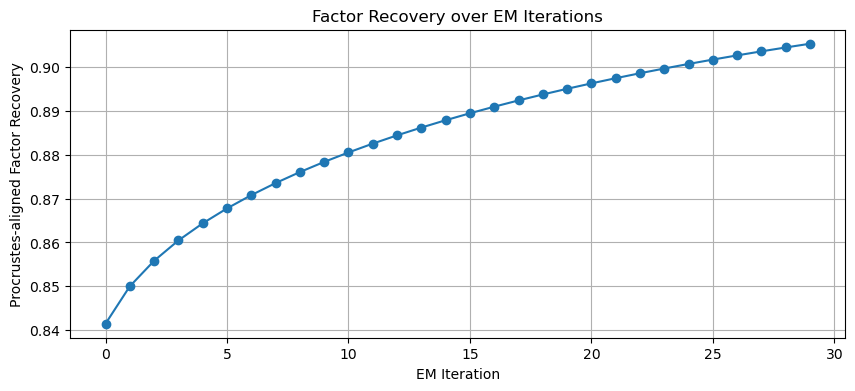

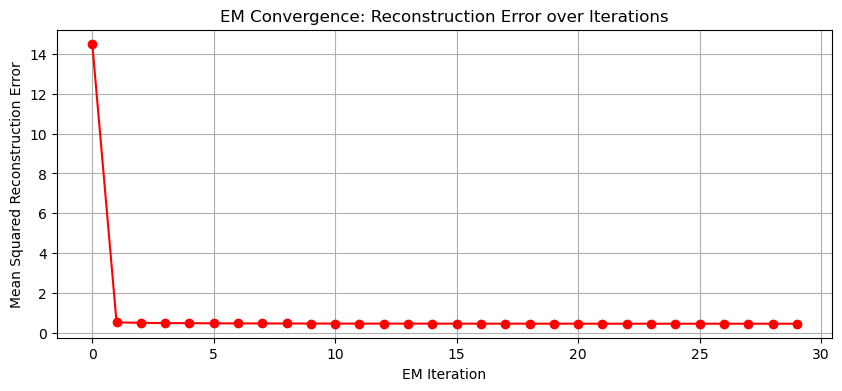

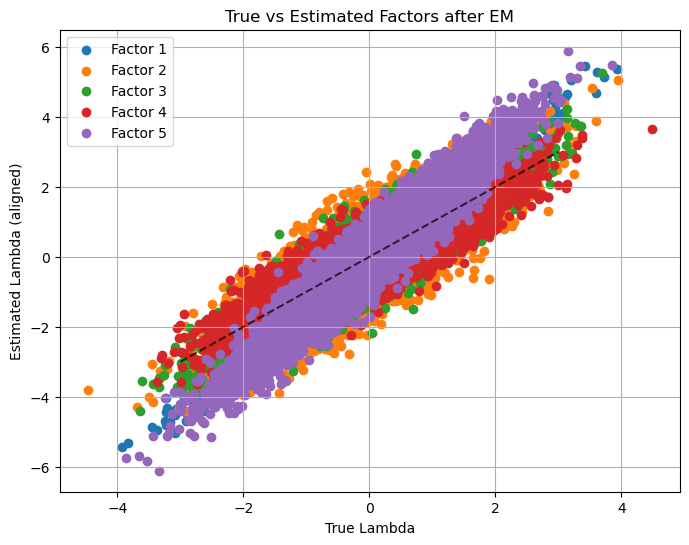

In [14]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import orthogonal_procrustes

# -------------------------------
# EM with history and reconstruction error
# -------------------------------
def run_em_with_history(Ys, dts_all, k=5, n_iter=30):
    p = Ys[0].shape[1]
    Lambda = np.random.randn(p, k)
    Psi = np.eye(p)
    rho = 0.05
    Q = 1.0
    tau = 1.0
    lam = 1.0

    history_Lambda = []
    mean_abs_history = []
    recon_error_history = []

    for it in range(n_iter):
        # E-step
        Ezs = []
        Ezzs = []
        for Y, dt in zip(Ys, dts_all):
            Ez, Ezz = kalman_smoother(Y, Lambda, Psi, rho, Q, dt)
            Ezs.append(Ez)
            Ezzs.append(Ezz)

        # M-step
        Lambda = update_Lambda(Ezs, Ezzs, Ys, tau, lam)
        Psi = update_Psi(Ys, Ezs, Lambda)

        # Save history
        history_Lambda.append(Lambda.copy())
        mean_abs_history.append(np.mean(np.abs(Lambda)))

        # Compute mean squared reconstruction error
        mse = 0
        count = 0
        for Y, Ez in zip(Ys, Ezs):
            Y_hat = Ez @ Lambda.T
            mse += np.sum((Y - Y_hat)**2)
            count += Y.size
        recon_error_history.append(mse / count)

        print(f"Iter {it:02d} | mean|Λ|={np.mean(np.abs(Lambda)):.3f} | MSE={recon_error_history[-1]:.4f}")

    return Lambda, history_Lambda, mean_abs_history, recon_error_history

# -------------------------------
# Visualization
# -------------------------------
def plot_em_performance(Lambda_true, history_Lambda, recon_error_history):
    n_iter = len(history_Lambda)
    k = Lambda_true.shape[1]

    # Factor recovery over iterations
    recovery = []
    for L_est in history_Lambda:
        R, _ = orthogonal_procrustes(L_est, Lambda_true)
        L_aligned = L_est @ R
        corr = np.corrcoef(Lambda_true.ravel(), L_aligned.ravel())[0,1]
        recovery.append(corr)

    # Plot factor recovery
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recovery, marker='o')
    plt.xlabel("EM Iteration")
    plt.ylabel("Procrustes-aligned Factor Recovery")
    plt.title("Factor Recovery over EM Iterations")
    plt.grid(True)
    plt.show()

    # Plot reconstruction error
    plt.figure(figsize=(10,4))
    plt.plot(range(n_iter), recon_error_history, marker='o', color='r')
    plt.xlabel("EM Iteration")
    plt.ylabel("Mean Squared Reconstruction Error")
    plt.title("EM Convergence: Reconstruction Error over Iterations")
    plt.grid(True)
    plt.show()

    # True vs Estimated factors (final)
    L_final = history_Lambda[-1]
    R, _ = orthogonal_procrustes(L_final, Lambda_true)
    L_aligned = L_final @ R

    plt.figure(figsize=(8,6))
    for i in range(k):
        plt.scatter(Lambda_true[:, i], L_aligned[:, i], label=f"Factor {i+1}")
    plt.plot([-3,3], [-3,3], 'k--', alpha=0.7)
    plt.xlabel("True Lambda")
    plt.ylabel("Estimated Lambda (aligned)")
    plt.title("True vs Estimated Factors after EM")
    plt.legend()
    plt.grid(True)
    plt.show()

# -------------------------------
# Main
# -------------------------------
def main_vis():
    n_subjects = 10
    T_list = [5,4,6,5,7,4,5,6,5,5]  # irregular T per subject
    Ys, Zs, Lambda_true, dts_all = simulate_ou_dfa(
        n_subjects=n_subjects,
        T_list=T_list,
        p=8000,
        k=5,
        rho=0.05,
        Q=1.0,
        Psi_scale=0.5
    )

    Lambda_est, history_Lambda, mean_abs_history, recon_error_history = run_em_with_history(Ys, dts_all, k=5, n_iter=30)
    rec = factor_recovery(Lambda_true, Lambda_est)
    print("\nProcrustes-aligned factor recovery:", rec)

    plot_em_performance(Lambda_true, history_Lambda, recon_error_history)

if __name__=="__main__":
    main_vis()
